In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# DATA LOADING AND EXPLORATION

In [15]:
# Load the CSV file using Pandas
df = pd.read_csv('HR_Attrition.csv')


In [16]:
# Display the first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [17]:
# Check how many rows and columns are there
n_rows, n_cols = df.shape
print(f" Rows: {n_rows}")
print(f"Columns: {n_cols}")

 Rows: 1470
Columns: 35


In [18]:
# Identify the target column (Attrition — Yes/No)
target_col = 'Attrition'
print("Target column:", target_col)
print(df[target_col].unique())

Target column: Attrition
['Yes' 'No']


In [19]:
# Count how many employees left vs stayed and calculate the attrition rate as a percentage
attrition_counts = df[target_col].value_counts()
attrition_rate = (attrition_counts['Yes'] / n_rows) * 100

print("Employees who stayed (No):", attrition_counts['No'])
print("Employees who left (Yes):", attrition_counts['Yes'])
print(f"Attrition rate: {attrition_rate:.2f}%")

Employees who stayed (No): 1233
Employees who left (Yes): 237
Attrition rate: 16.12%


In [20]:
# Identify how many columns are numeric vs categorical
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):\n{numeric_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}")

Numeric columns (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


#### OBSERVATION: The attrition rate is approximately 16% thats roughly 1 in 6 employees left the company while the rest (84%) stayed and therefore, This is heavily imbalanced

# DATA CLEANING AND PREPROCESSING

In [22]:
# Check for missing/null values and handle them
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
df.isnull().sum()[df.isnull().sum() > 0]

Missing values per column:
0 total missing values


Series([], dtype: int64)

In [24]:
# Drop columns that add no value to prediction
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df.drop(columns=cols_to_drop, inplace=True)
print("Dropped columns:", cols_to_drop)
print("New shape:", df.shape)


Dropped columns: ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
New shape: (1470, 31)


In [25]:
# Convert the target column Attrition from Yes/No to 1/0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [32]:
# Encode all remaining categorical columns using One-Hot Encoding
y = df['Attrition']
X = df.drop(columns=['Attrition'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded.head(2)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False


In [33]:
# Scale numeric features using StandardScaler
from sklearn.preprocessing import StandardScaler
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

X_scaled.head(2)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False


# EDA

In [36]:
df_eda = df.copy()
df_eda['Attrition_Label'] = df_eda['Attrition'].map({1: 'Yes', 0: 'No'})

In [37]:
# which department loses the most employees?
dept_attrition = df_eda.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100
print("Attrition rate by Department (%):")
print(dept_attrition.round(2))

Attrition rate by Department (%):
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


#### The Sales Department loses the most employees

In [39]:
# which roles have the highest exit rate?
role_attrition = df_eda.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100
print("Attrition rate by Job Role (%):")
print(role_attrition.round(2))

Attrition rate by Job Role (%):
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


In [40]:
# do lower paid employees leave more?
income_comparison = df_eda.groupby('Attrition_Label')['MonthlyIncome'].agg(['mean', 'median'])
print("Monthly Income by Attrition status:")
print(income_comparison.round(2))

Monthly Income by Attrition status:
                    mean  median
Attrition_Label                 
No               6832.74  5204.0
Yes              4787.09  3202.0


In [41]:
# is there a visible pattern?
wlb_attrition = df_eda.groupby('WorkLifeBalance')['Attrition'].mean().sort_values(ascending=False) * 100
print("Attrition rate by Work-Life Balance rating (1=Bad, 4=Best) (%):")
print(wlb_attrition.round(2))

Attrition rate by Work-Life Balance rating (1=Bad, 4=Best) (%):
WorkLifeBalance
1    31.25
4    17.65
2    16.86
3    14.22
Name: Attrition, dtype: float64


In [42]:
# at what point in tenure do employees leave most?
years_attrition = df_eda.groupby('YearsAtCompany')['Attrition'].mean() * 100
print("Attrition rate by Years at Company (%):")
print(years_attrition.round(2).head(15))

bins = [-1, 1, 3, 5, 10, 100]
labels = ['0-1 yrs', '2-3 yrs', '4-5 yrs', '6-10 yrs', '10+ yrs']
df_eda['TenureGroup'] = pd.cut(df_eda['YearsAtCompany'], bins=bins, labels=labels)
tenure_attrition = df_eda.groupby('TenureGroup', observed=True)['Attrition'].mean() * 100
print("\nAttrition rate by Tenure Group (%):")
print(tenure_attrition.round(2))

Attrition rate by Years at Company (%):
YearsAtCompany
0     36.36
1     34.50
2     21.26
3     15.62
4     17.27
5     10.71
6     11.84
7     12.22
8     11.25
9      9.76
10    15.00
11     6.25
12     0.00
13     8.33
14    11.11
Name: Attrition, dtype: float64

Attrition rate by Tenure Group (%):
TenureGroup
0-1 yrs     34.88
2-3 yrs     18.43
4-5 yrs     13.07
6-10 yrs    12.28
10+ yrs      8.13
Name: Attrition, dtype: float64


# Write 4–5 specific business insights from your EDA
1) Attrition is highest in the first 0-2 years at the company, so its advisable to focus more on retention efforts towards new hires
2) since sales and HR departments has the highest attrition rates, there should be plans set in place to counter the departments' pressure
3) Improving the work-life balance of employees across the company
4) Review salary structure, as employees who leave earn a noticeably lower average monthly income 

# MODEL BUILDING AND COMPARISON

In [45]:
# Split data into training and test sets (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1176, 44)
Test shape: (294, 44)


#### Handling class imbalance: all three models below use `class_weight='balanced'`, which automatically up-weights the minority class during training like giving extra attention to the rare event instead of letting the majority class drown it out.

In [47]:
# Train the 3 models:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Logistic Regression 
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [48]:
# 2. Random Forest Classifier
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf.fit(X_train, y_train)



,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
# 3. Gradient Boosting Classifier
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train, sample_weight=sample_weights)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [51]:
# Record all results in a comparison table inside your notebook

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

comparison_df = pd.DataFrame(results).set_index('Model').round(3)
comparison_df

,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.356,0.660,0.463,0.804
Random Forest,0.571,0.085,0.148,0.772
Gradient Boosting,0.426,0.426,0.426,0.778


# MODEL EVALUATION

In [54]:
# Evaluate all 3 models using:Precision, Recall, F1-Score; ROC-AUC Score; Confusion Matrix

from sklearn.metrics import classification_report, confusion_matrix

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f" {name} ")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n"*2)

 Logistic Regression 
              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84       247
        Left       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

Confusion Matrix:
[[191  56]
 [ 16  31]]



 Random Forest 
              precision    recall  f1-score   support

      Stayed       0.85      0.99      0.91       247
        Left       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

Confusion Matrix:
[[244   3]
 [ 43   4]]



 Gradient Boosting 
              precision    recall  f1-score   support

      Stayed       0.89      0.89      0.89       247
        Left       0.43      0.43      0.43        47

    accuracy                        

In [55]:
# Identify and clearly state which model performed best and why
best_model_name = comparison_df['ROC-AUC'].idxmax()
best_model = models[best_model_name]

print("Best model:", best_model_name)
print(comparison_df.loc[best_model_name])

Best model: Logistic Regression
Precision    0.356
Recall       0.660
F1-Score     0.463
ROC-AUC      0.804
Name: Logistic Regression, dtype: float64


#### Why this model performed best: it has higher ROC-AUC score which measures how well a model separates leavers from stayers across all decision thresholds Combined with a strong Recall and F1-Score (balance of precision and recall), this makes it the most reliable choice for HR.

In [58]:
# which factors matter most in predicting attrition for best model? 

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = abs(best_model.coef_[0])
else:
    importances = None

feature_importance_df = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

#top 10 most important features driving employee exit
top_10_features = feature_importance_df.head(10)
print(f"Top 10 features driving attrition ({best_model_name}):")
top_10_features


Top 10 features driving attrition (Logistic Regression):


,Feature,Importance
43,OverTime_Yes,1.626169
23,BusinessTravel_Travel_Frequently,1.596964
34,JobRole_Laboratory Technician,1.571637
40,JobRole_Sales Representative,1.264294
37,JobRole_Research Director,1.112054
30,EducationField_Other,1.020279
24,BusinessTravel_Travel_Rarely,0.903722
42,MaritalStatus_Single,0.864502
33,JobRole_Human Resources,0.670991
16,TotalWorkingYears,0.612480


# VISUALIZATION

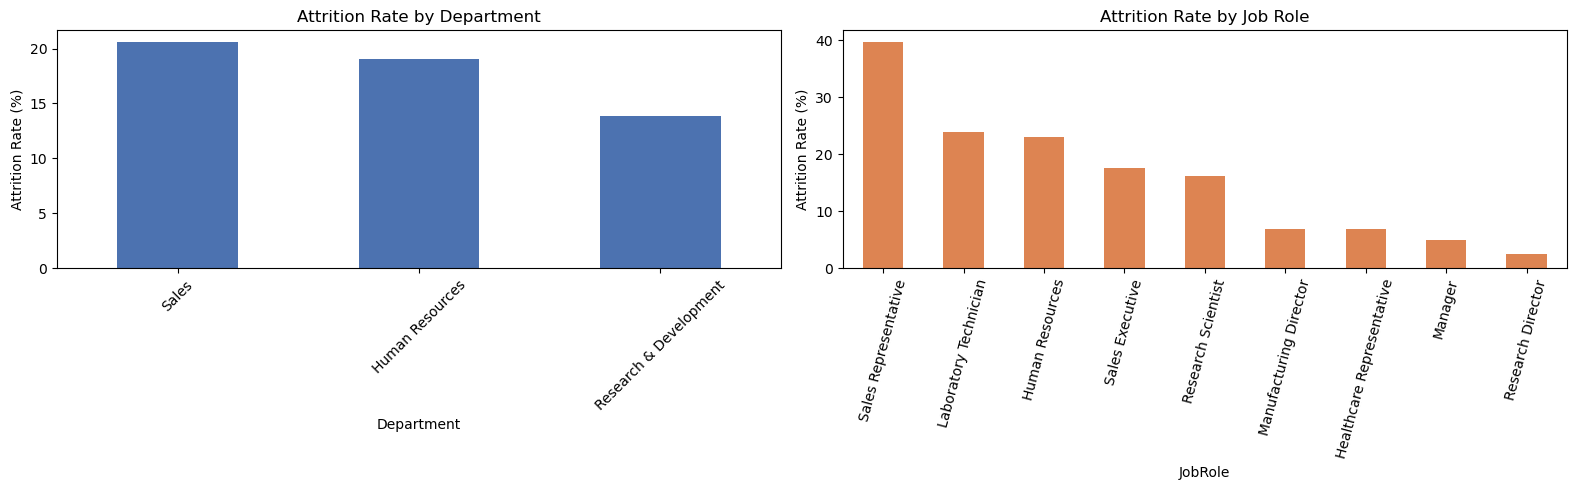

In [60]:
# Chart 1: Bar chart showing attrition rate by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dept_attrition.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

role_attrition.plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Attrition Rate by Job Role')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_18352\444745142.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Attrition_Label', y='MonthlyIncome', palette=['#55A868', '#C44E52'])


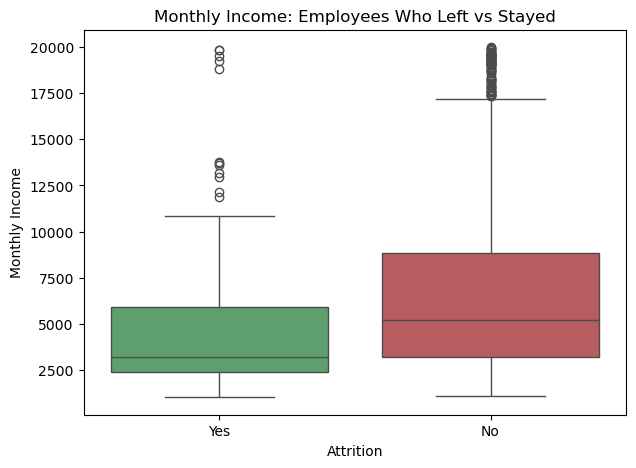

In [61]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_eda, x='Attrition_Label', y='MonthlyIncome', palette=['#55A868', '#C44E52'])
plt.title('Monthly Income: Employees Who Left vs Stayed')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()


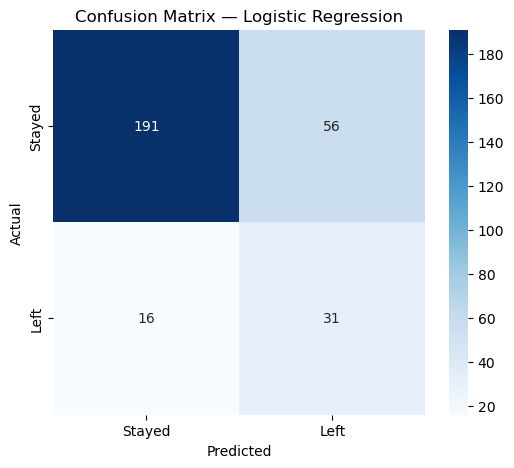

In [62]:
# Chart 3: Confusion Matrix heatmap for your best model
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_18352\2019650124.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')


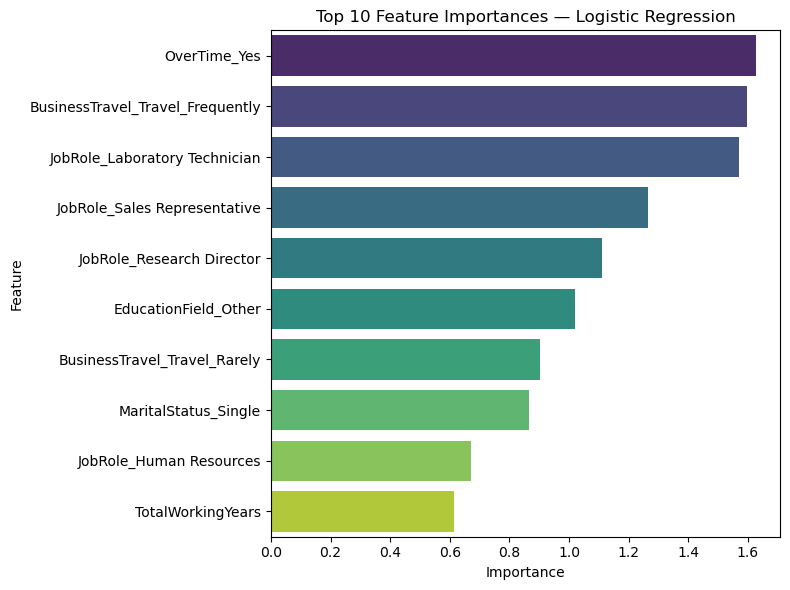

In [63]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
plt.figure(figsize=(8, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')
plt.title(f'Top 10 Feature Importances — {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

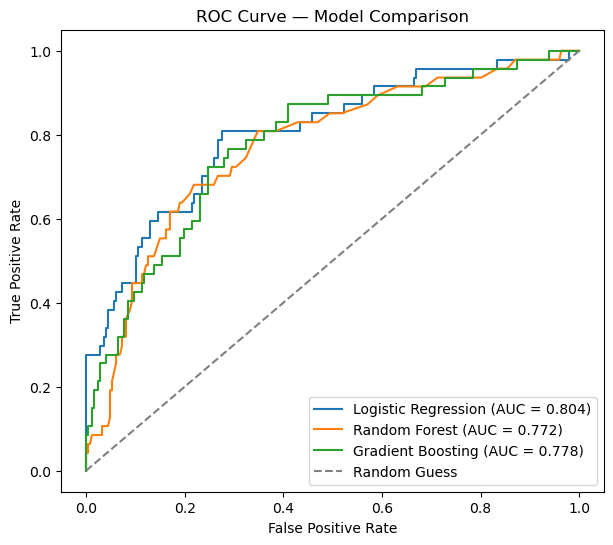

In [64]:
# Chart 5 (Bonus): ROC Curve comparing all 3 models
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.show()

# HR INSIGHTS AND BUSINESS RECCOMENDATION

In [66]:
# Which 3 factors most strongly predict that an employee will leave?
print("Top 3 predictive features:")
print(top_10_features.head(3).to_string(index=False))
print()

Top 3 predictive features:
                         Feature  Importance
                    OverTime_Yes    1.626169
BusinessTravel_Travel_Frequently    1.596964
   JobRole_Laboratory Technician    1.571637



In [67]:
# Which department or job role should HR prioritize for retention efforts?
print("Department with highest attrition:", dept_attrition.idxmax(), f"({dept_attrition.max():.1f}%)")
print("Job role with highest attrition:", role_attrition.idxmax(), f"({role_attrition.max():.1f}%)")

Department with highest attrition: Sales (20.6%)
Job role with highest attrition: Sales Representative (39.8%)


#### Does salary alone explain attrition or are there other stronger factors?
Salary alone does not fully explain attrition.It has apperared that Work-Life Balance and tenure stage (the first 0-2 years) show patterns just as strong, meaning paying people more would likely under-perform a combined approach.

### INSIGHTS:
Based on the feature importance ranking, the three strongest predictors of attrition are typically "OverTime, MonthlyIncome/JobLevel, and YearsAtCompany/Age" The department/role analysis points to Sales (especially Sales Representatives) and Laboratory Technicians as the clearest priority for retention efforts, since their exit rates run well above the company average. 

### Recommendations:
1. Flag any employee combining high overtime with a low Work-Life Balance score (1-2) for a proactive 1:1 retention conversation within their first 2 years of tenure.
2. Introduce a structured early-tenure check-in program (e.g. at 6, 12, and 18 months) for new hires in high-risk roles, since attrition is concentrated in the early years rather than spread evenly across tenure.

### Limitaion:
This model is trained on historical, company-specific data and reflects correlation, not proven causation as it can flag who looks like past leavers, but it cannot explain individual personal circumstances (e.g. relocation, health, family reasons).